In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy
from statsmodels.nonparametric.smoothers_lowess import lowess 

In [115]:
notes = pd.read_parquet('students/ryder/sample_user_note_traj.parquet')
ratings = pd.read_parquet('students/ryder/sample_user_rating_traj.parquet')
request = pd.read_parquet('students/ryder/sample_user_request_traj.parquet')

In [78]:
ratings_sorted = ratings.sort_values("calendarMonth", ascending=False)
ratings_sorted.tail(1000)

,raterParticipantId,userMonth,sportsRatedCount,diaries_&_daily_lifeRatedCount,business_&_entrepreneursRatedCount,science_&_technologyRatedCount,news_&_social_concernRatedCount,otherRatedCount,calendarMonth,notesRated,...,proRepNNRatings,proRepNNNRatings,antiRepNNNRatings,overallAccuracy,helpfulNotHelpfulFactorDiff,helpfulNotHelpfulInterceptDiff,proDemRatings,antiDemRatings,proRepRatings,antiRepRatings
45779,ADFD3931625A6727850A7A2BCE5324126E3C1D0A1DD45D...,0,0,0,0,0,1,0,2022-12,1,...,0,0,0,1.000000,NaN,NaN,0,0,0,0
30370,7374D631C588AA6770EF62467E20939FBD3A1EAB7A88AA...,1,0,0,0,0,1,0,2022-12,1,...,0,0,0,1.000000,NaN,NaN,0,0,0,0
37493,8E924D5A9D7102A6531B9621ABCF9CA46EA551D103E08F...,15,0,0,0,1,4,0,2022-12,5,...,0,0,0,0.400000,-0.97582,0.146559,0,0,0,0
52343,C4D924EA36367D8720E9C93199A677B31F72F9F0DD3E66...,0,0,0,0,0,1,0,2022-12,1,...,0,0,0,1.000000,NaN,NaN,0,0,0,0
35697,889CEE9B052912CC2706D911F8D2A07BC1F3D9275246E2...,21,0,0,0,0,1,1,2022-12,3,...,0,0,0,0.333333,-0.96893,0.020712,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35691,889CEE9B052912CC2706D911F8D2A07BC1F3D9275246E2...,0,0,0,0,0,1,1,2021-03,2,...,0,0,0,0.000000,NaN,NaN,0,0,0,0
16690,3F8A4B535462478897F16C5AAB63BC6322BA2CF9AF76BF...,0,0,3,0,2,14,4,2021-03,29,...,0,0,0,0.000000,NaN,NaN,0,0,0,0
42341,A13D29CCCBF599E2C1AEFA4E3C5104189E01E5D5D9322D...,0,0,0,0,0,2,0,2021-02,4,...,0,0,0,0.000000,NaN,NaN,0,0,0,0
34911,85BBDB7F2E2A2028037E9084ED585FB12ED1215E118930...,1,0,0,0,0,1,0,2021-02,2,...,0,0,0,0.000000,NaN,NaN,0,0,0,0


In [15]:
notes.head()

,noteAuthorParticipantId,userMonth,sportsCount,diaries_&_daily_lifeCount,business_&_entrepreneursCount,science_&_technologyCount,news_&_social_concernCount,otherCount,calendarMonth,notesCreated,hitRate,hits,avgNoteFactor,avgNoteIntercept,topicsTargeted,avgRatingsEarned
0,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,16,0,0,0,0,1,0,2024-11,1,0.0,0,0.495189,0.131059,1,53.000000
1,0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...,18,0,0,0,0,0,1,2025-01,1,0.0,0,-0.056279,-0.021759,1,11.000000
2,004BAF746629CC246C75D468FC9B32ADCE2F632DE32B33...,17,0,0,0,0,2,0,2024-07,2,0.0,0,0.263370,0.109354,1,18.500000
3,004BAF746629CC246C75D468FC9B32ADCE2F632DE32B33...,18,0,0,0,0,3,0,2024-08,3,0.0,0,0.389272,0.086647,1,21.666667
4,004BAF746629CC246C75D468FC9B32ADCE2F632DE32B33...,27,0,0,0,0,1,0,2025-05,1,0.0,0,0.047417,0.122497,1,6.000000


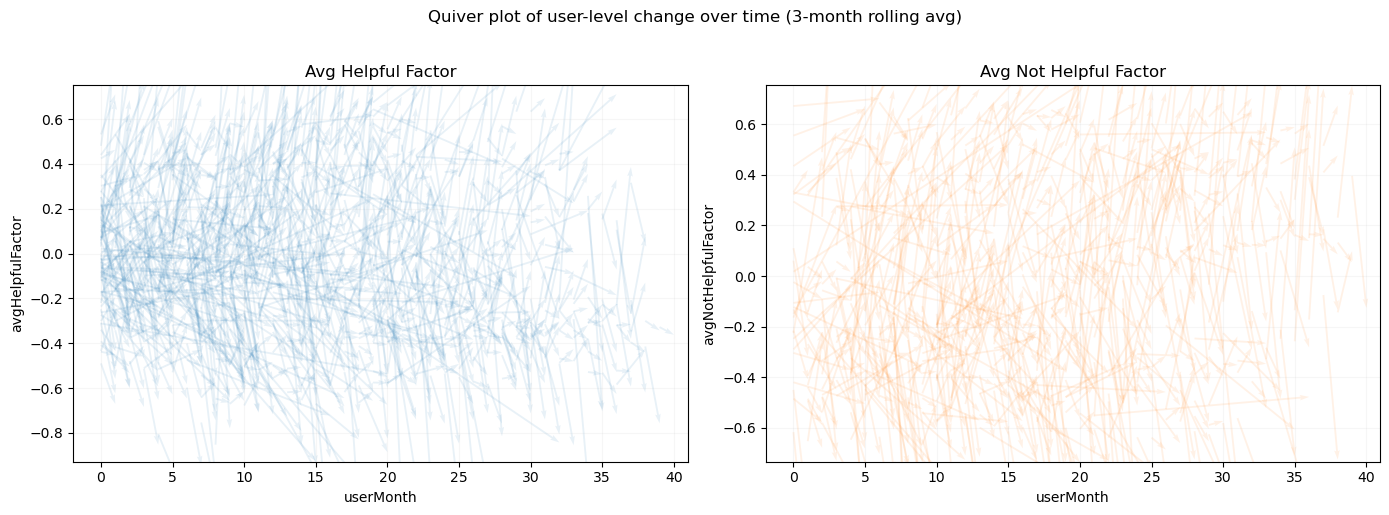

In [16]:
from matplotlib.collections import LineCollection


plot_specs = [
    ("avgHelpfulFactor", "Avg Helpful Factor", "tab:blue"),
    ("avgNotHelpfulFactor", "Avg Not Helpful Factor", "tab:orange"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Rebuild the figure using a random sample of 100 users and quiver arrows over time
rng = np.random.default_rng(42)
eligible_users = (
    ratings.groupby("raterParticipantId")["userMonth"]
    .nunique()
    .loc[lambda s: s >= 3]
    .index.to_numpy()
)

sample_users = rng.choice(
    eligible_users,
    size=min(100, len(eligible_users)),
    replace=False
)

sampled = ratings[ratings["raterParticipantId"].isin(sample_users)].copy()

# Smooth user avg factors with rolling average
for ax, (y_col, title, color) in zip(axes, plot_specs):
    ax.clear()
    cols = ["raterParticipantId", "userMonth", "notesRated", y_col]
    dfq = sampled[cols].dropna().sort_values(["raterParticipantId", "userMonth"])

    for _, g in dfq.groupby("raterParticipantId"):
        if len(g) < 2:
            continue

        x = g["userMonth"].to_numpy()
        y = g[y_col].to_numpy()

        # Rolling average for y values
        y_smooth = pd.Series(y).rolling(window=5, center=True, min_periods=1).mean().to_numpy()

        dx = np.diff(x)
        dy = np.diff(y_smooth)

        ax.quiver(
            x[:-1], y_smooth[:-1], dx, dy,
            angles="xy", scale_units="xy", scale=1,
            color=color, alpha=0.1, width=0.003
        )

    ax.autoscale()
    ax.set_title(f"{title}")
plt.suptitle("Faceted scatterplots of notesRated vs factor scores", y=1.02)
plt.tight_layout()

for ax, (y_col, title, color) in zip(axes, plot_specs):
    ax.clear()
    cols = ["raterParticipantId", "userMonth", y_col]
    dfq = sampled[cols].dropna().sort_values(["raterParticipantId", "userMonth"])

    for _, g in dfq.groupby("raterParticipantId"):
        if len(g) < 2:
            continue
        x = g["userMonth"].to_numpy()
        y = g[y_col].to_numpy()

        ax.quiver(
            x[:-1], y[:-1],
            np.diff(x), np.diff(y),
            angles="xy", scale_units="xy", scale=1,
            color=color, alpha=0.05, width=0.002
        )

    ax.set_title(f"{title} (100 random users)")
    ax.set_xlabel("userMonth")
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.1)

plt.suptitle("Quiver plot of user-level change over time", y=1.02)
plt.tight_layout()
# Redraw with arrow-segment thickness mapped to "new ratings in month" (notesRated at t+1)
for ax, (y_col, title, color) in zip(axes, plot_specs):
    ax.clear()
    cols = ["raterParticipantId", "userMonth", "notesRated", y_col]
    dfq = sampled[cols].dropna().sort_values(["raterParticipantId", "userMonth"])

    for _, g in dfq.groupby("raterParticipantId"):
        if len(g) < 2:
            continue

        x = g["userMonth"].to_numpy()
        y = g[y_col].to_numpy()
        n = g["notesRated"].to_numpy()

        dx = np.diff(x)
        dy = np.diff(y)

        # "new ratings in a month" for each segment: destination month's notesRated
        new_ratings = n[1:].astype(float)

        # Thickness scaling (compressed to reduce outlier dominance)
        scale_vals = np.sqrt(np.clip(new_ratings, 0, None))
        denom = scale_vals.max() if scale_vals.max() > 0 else 1.0
        lws = 0.2 + 2.8 * (scale_vals / denom)

        # Variable-thickness segments
        segs = np.stack(
            [np.column_stack([x[:-1], y[:-1]]), np.column_stack([x[1:], y[1:]])],
            axis=1
        )
        lc = LineCollection(segs, colors=color, linewidths=lws, alpha=0.07)
        ax.add_collection(lc)

        # Arrowheads
        ax.quiver(
            x[:-1], y[:-1], dx, dy,
            angles="xy", scale_units="xy", scale=1,
            color=color, alpha=0.07, width=0.0012
        )

    ax.autoscale()
    ax.set_title(f"{title} (thickness ∝ new monthly ratings)")
    ax.set_xlabel("userMonth")
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.1)

plt.suptitle("Quiver plot of user-level change over time", y=1.02)
plt.tight_layout()
# Smooth user avg factors with rolling average of every three months
for ax, (y_col, title, color) in zip(axes, plot_specs):
    ax.clear()
    cols = ["raterParticipantId", "userMonth", "notesRated", y_col]
    dfq = sampled[cols].dropna().sort_values(["raterParticipantId", "userMonth"])

    for _, g in dfq.groupby("raterParticipantId"):
        if len(g) < 2:
            continue

        x = g["userMonth"].to_numpy()
        y = g[y_col].to_numpy()
        n = g["notesRated"].to_numpy()

        dx = np.diff(x)
        dy = np.diff(y)

        # "new ratings in a month" for each segment: destination month's notesRated
        new_ratings = n[1:].astype(float)

        # Thickness scaling (compressed to reduce outlier dominance)
        scale_vals = np.sqrt(np.clip(new_ratings, 0, None))
        denom = scale_vals.max() if scale_vals.max() > 0 else 1.0
        lws = 0.2 + 2.8 * (scale_vals / denom)

        # Rolling average for y values (window=3, center=True)
        y_smooth = pd.Series(y).rolling(window=5, center=True, min_periods=1).mean().to_numpy()

        # Variable-thickness segments using smoothed y values
        # segs = np.stack(
            # [np.column_stack([x[:-1], y_smooth[:-1]]), np.column_stack([x[1:], y_smooth[1:]])],
            # axis=1
        # )
        # lc = LineCollection(segs, colors=color, linewidths=lws, alpha=0.07)
        # ax.add_collection(lc)

        # Arrowheads (still use original y for direction)
        ax.quiver(
            x[:-1], y_smooth[:-1], dx, dy,
            angles="xy", scale_units="xy", scale=1,
            color=color, alpha=0.1, width=0.003
        )

    ax.autoscale()
    ax.set_title(f"{title}")
    ax.set_xlabel("userMonth")
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.1)

plt.suptitle("Quiver plot of user-level change over time (3-month rolling avg)", y=1.02)
plt.tight_layout()
plt.show()

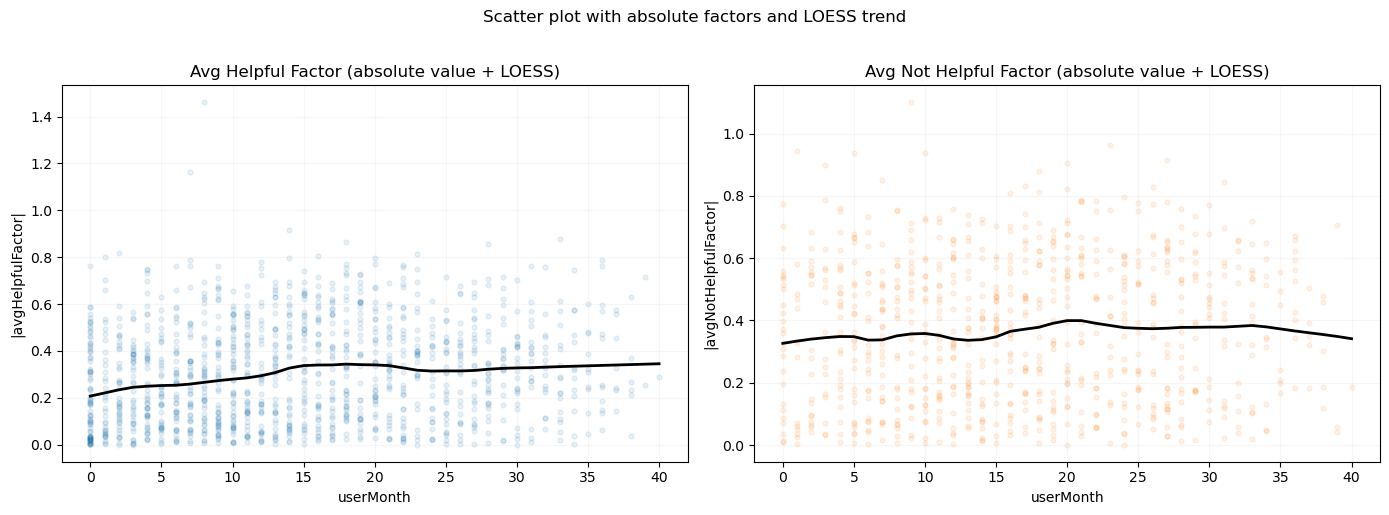

In [ ]:
# Replicate the quiver plots as scatterplots for both factors
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, (y_col, title, color) in zip(axes, plot_specs):
    cols = ["raterParticipantId", "userMonth", y_col]
    dfq = sampled[cols].dropna().sort_values(["raterParticipantId", "userMonth"])

    for _, g in dfq.groupby("raterParticipantId"):
        if len(g) < 2:
            continue
        x = g["userMonth"].to_numpy()
        y = g[y_col].to_numpy()
        ax.scatter(x, y, color=color, alpha=0.005, s=12)

    ax.set_title(f"{title} (100 random users)")
    ax.set_xlabel("userMonth")
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.02)

plt.suptitle("Scatter plot of user-level change over time", y=1.02)
plt.tight_layout()
for ax, (y_col, title, color) in zip(axes, plot_specs):
    ax.clear()
    cols = ["userMonth", y_col]
    dfq = sampled[cols].dropna().copy()
    dfq[y_col] = dfq[y_col].abs()

    ax.scatter(
        dfq["userMonth"],
        dfq[y_col],
        color=color,
        alpha=0.1,
        s=12
    )

    if len(dfq) > 1:
        smooth = lowess(dfq[y_col], dfq["userMonth"], frac=0.2, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1], color="black", linewidth=2)

    ax.set_title(f"{title} (absolute value + LOESS)")
    ax.set_xlabel("userMonth")
    ax.set_ylabel(f"|{y_col}|")
    ax.grid(True, alpha=0.1)

plt.suptitle("Scatter plot with absolute factors and LOESS trend", y=1.02)
plt.tight_layout()
plt.show()

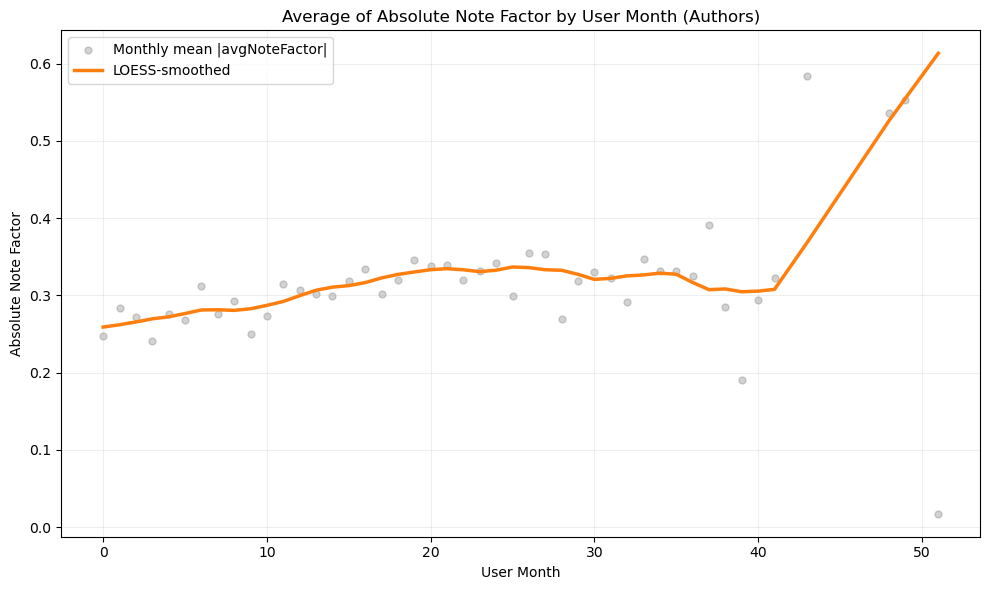

In [ ]:
author_note_factors = notes[["userMonth", "avgNoteFactor"]].dropna().copy()
author_note_factors["absNoteFactor"] = author_note_factors["avgNoteFactor"].abs()

monthly_abs = (
    author_note_factors
    .groupby("userMonth", as_index=False)["absNoteFactor"]
    .mean()
    .sort_values("userMonth")
)

monthly_abs["roll3_absNoteFactor"] = (
    monthly_abs["absNoteFactor"]
    .rolling(window=5, min_periods=1)
    .mean()
)

overall_smooth = lowess(
    monthly_abs["absNoteFactor"],
    monthly_abs["userMonth"],
    frac=0.2,
    return_sorted=True
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    monthly_abs["userMonth"],
    monthly_abs["absNoteFactor"],
    color="tab:gray",
    alpha=0.35,
    s=25,
    label="Monthly mean |avgNoteFactor|"
)
ax.plot(
    overall_smooth[:, 0],
    overall_smooth[:, 1],
    color="tab:orange",
    linewidth=2.5,
    label="LOESS-smoothed"
)

ax.set_title("Average of Absolute Note Factor by User Month (Authors)")
ax.set_xlabel("User Month")
ax.set_ylabel("Absolute Note Factor")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

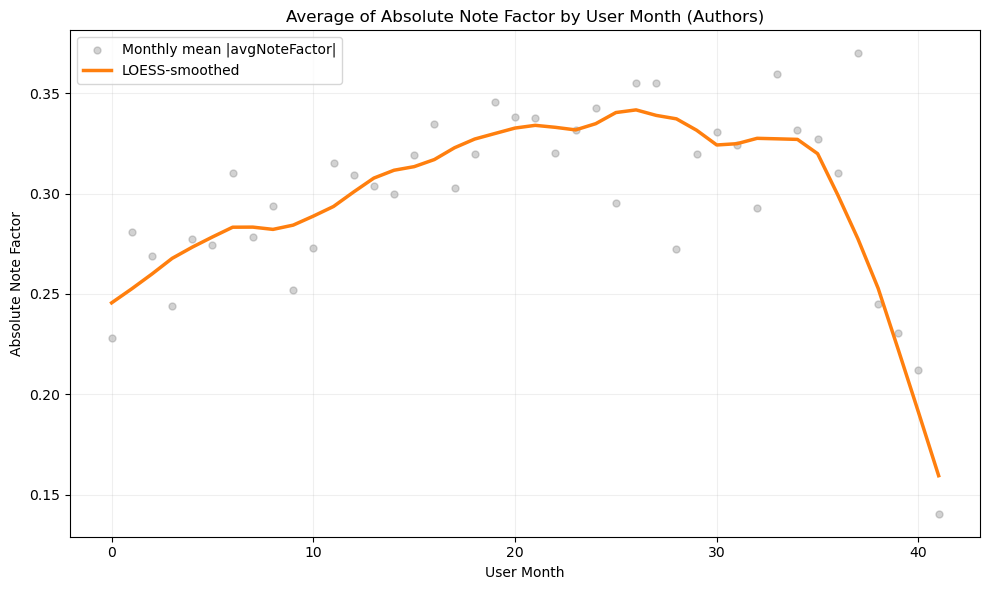

In [ ]:
# Filter notes to authors whose first observed month is 2022-11 or later

first_note_month = (
    notes.groupby("noteAuthorParticipantId", as_index=False)["calendarMonth"]
    .min()
    .rename(columns={"calendarMonth": "firstCalendarMonth"})
)

keep_author_ids = first_note_month.loc[
    first_note_month["firstCalendarMonth"] >= "2022-11",
    "noteAuthorParticipantId"
]

notes_trimmed = notes[notes["noteAuthorParticipantId"].isin(keep_author_ids)].copy()
notes = notes_trimmed

author_note_factors = notes_trimmed[["userMonth", "avgNoteFactor"]].dropna().copy()
author_note_factors["absNoteFactor"] = author_note_factors["avgNoteFactor"].abs()

monthly_abs = (
    author_note_factors
    .groupby("userMonth", as_index=False)["absNoteFactor"]
    .mean()
    .sort_values("userMonth")
)

monthly_abs["roll3_absNoteFactor"] = (
    monthly_abs["absNoteFactor"]
    .rolling(window=5, min_periods=1)
    .mean()
)

overall_smooth = lowess(
    monthly_abs["absNoteFactor"],
    monthly_abs["userMonth"],
    frac=0.2,
    return_sorted=True
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    monthly_abs["userMonth"],
    monthly_abs["absNoteFactor"],
    color="tab:gray",
    alpha=0.35,
    s=25,
    label="Monthly mean |avgNoteFactor|"
)
ax.plot(
    overall_smooth[:, 0],
    overall_smooth[:, 1],
    color="tab:orange",
    linewidth=2.5,
    label="LOESS-smoothed"
)

ax.set_title("Average of Absolute Note Factor by User Month (Authors)")
ax.set_xlabel("User Month")
ax.set_ylabel("Absolute Note Factor")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

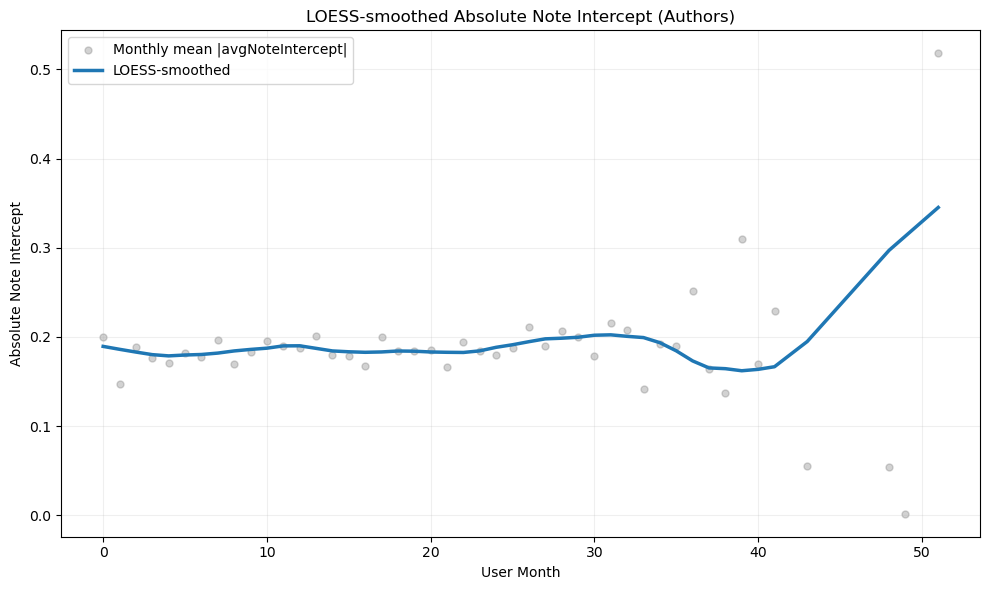

In [17]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# LOESS-smoothed absolute note intercept by note userMonth
author_note_intercepts = notes[["userMonth", "avgNoteIntercept"]].dropna().copy()
author_note_intercepts["absNoteIntercept"] = author_note_intercepts["avgNoteIntercept"].abs()

monthly_abs_intercept = (
    author_note_intercepts
    .groupby("userMonth", as_index=False)["absNoteIntercept"]
    .mean()
    .sort_values("userMonth")
)


loess_smoothed = lowess(
    monthly_abs_intercept["absNoteIntercept"],
    monthly_abs_intercept["userMonth"],
    frac=0.2,
    return_sorted=True
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    monthly_abs_intercept["userMonth"],
    monthly_abs_intercept["absNoteIntercept"],
    color="tab:gray",
    alpha=0.35,
    s=25,
    label="Monthly mean |avgNoteIntercept|"
)
ax.plot(
    loess_smoothed[:, 0],
    loess_smoothed[:, 1],
    color="tab:blue",
    linewidth=2.5,
    label="LOESS-smoothed"
)

ax.set_title("LOESS-smoothed Absolute Note Intercept (Authors)")
ax.set_xlabel("User Month")
ax.set_ylabel("Absolute Note Intercept")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

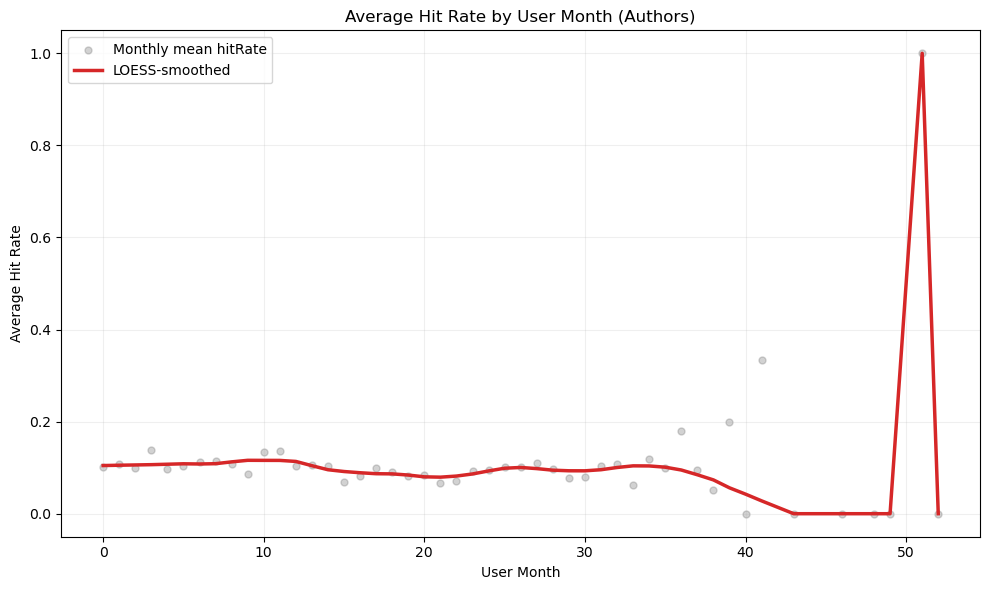

In [21]:
# Plot "hitRate" by author over userMonth
author_hitrate = notes[["userMonth", "hitRate"]].dropna().copy()

monthly_hitrate = (
    author_hitrate
    .groupby("userMonth", as_index=False)["hitRate"]
    .mean()
    .sort_values("userMonth")
)

hitrate_smooth = lowess(
    monthly_hitrate["hitRate"],
    monthly_hitrate["userMonth"],
    frac=0.2,
    return_sorted=True
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    monthly_hitrate["userMonth"],
    monthly_hitrate["hitRate"],
    color="tab:gray",
    alpha=0.35,
    s=25,
    label="Monthly mean hitRate"
)
ax.plot(
    hitrate_smooth[:, 0],
    hitrate_smooth[:, 1],
    color="tab:red",
    linewidth=2.5,
    label="LOESS-smoothed"
)

ax.set_title("Average Hit Rate by User Month (Authors)")
ax.set_xlabel("User Month")
ax.set_ylabel("Average Hit Rate")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

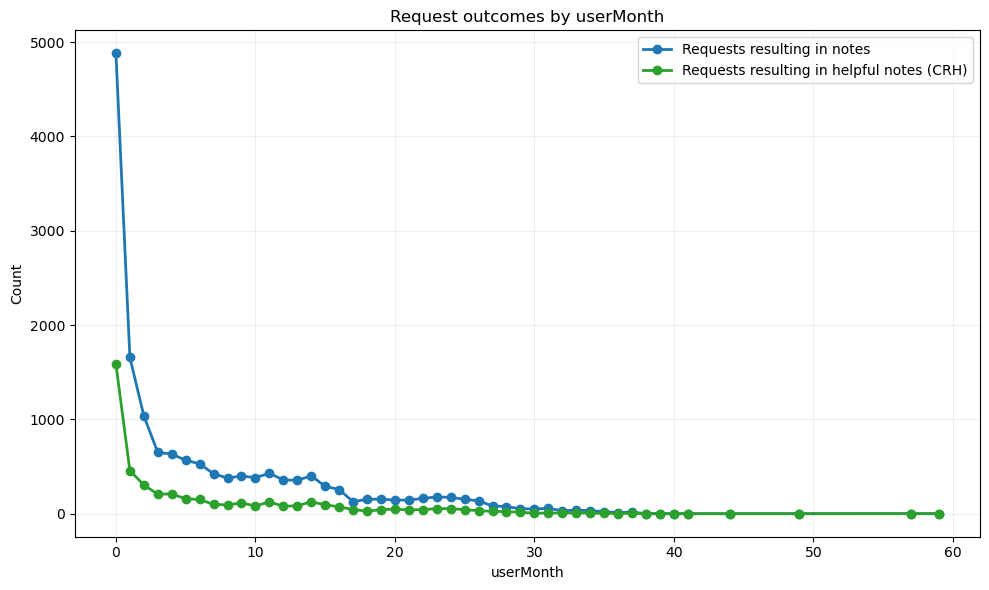

In [22]:
monthly_request_outcomes = (
    request.groupby("userMonth", as_index=False)[
        ["numRequestsResultingInNote", "numRequestsResultingInCrh"]
    ]
    .sum()
    .sort_values("userMonth")
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    monthly_request_outcomes["userMonth"],
    monthly_request_outcomes["numRequestsResultingInNote"],
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Requests resulting in notes"
)
ax.plot(
    monthly_request_outcomes["userMonth"],
    monthly_request_outcomes["numRequestsResultingInCrh"],
    marker="o",
    linewidth=2,
    color="tab:green",
    label="Requests resulting in helpful notes (CRH)"
)

ax.set_title("Request outcomes by userMonth")
ax.set_xlabel("userMonth")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

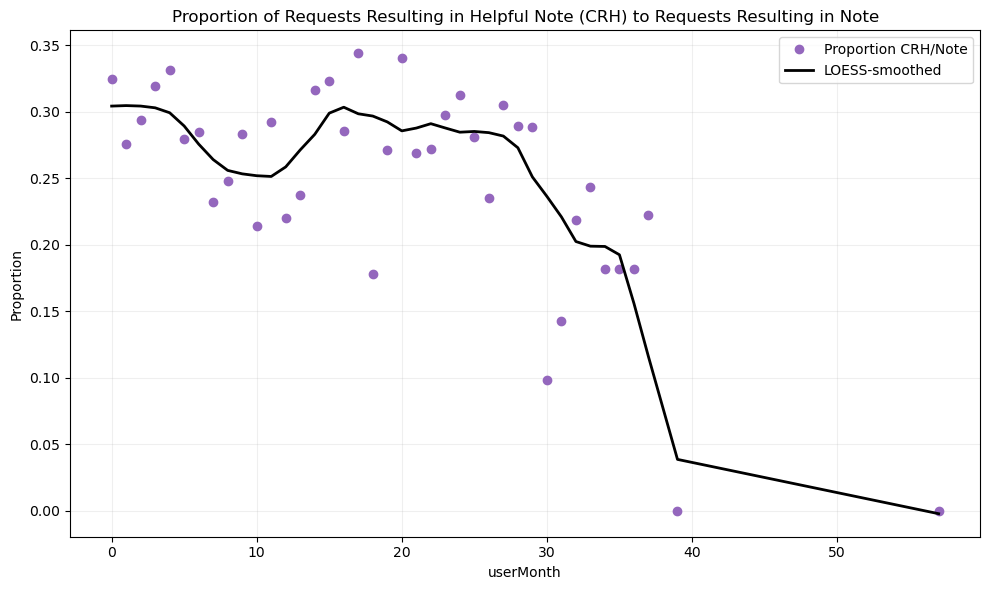

In [27]:
# Calculate the proportion of requests resulting in a helpful note (CRH) to requests resulting in a note
monthly_request_outcomes["prop_crh_to_note"] = (
    monthly_request_outcomes["numRequestsResultingInCrh"] /
    monthly_request_outcomes["numRequestsResultingInNote"].replace(0, np.nan)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    monthly_request_outcomes["userMonth"],
    monthly_request_outcomes["prop_crh_to_note"],
    marker="o",
    linewidth=0,
    color="tab:purple",
    label="Proportion CRH/Note"
)
loess_crh_note = lowess(
    monthly_request_outcomes["prop_crh_to_note"],
    monthly_request_outcomes["userMonth"],
    frac=0.2,
    return_sorted=True
)
ax.plot(
    loess_crh_note[:, 0],
    loess_crh_note[:, 1],
    color="black",
    linewidth=2,
    label="LOESS-smoothed"
)
ax.set_title("Proportion of Requests Resulting in Helpful Note (CRH) to Requests Resulting in Note")
ax.set_xlabel("userMonth")
ax.set_ylabel("Proportion")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

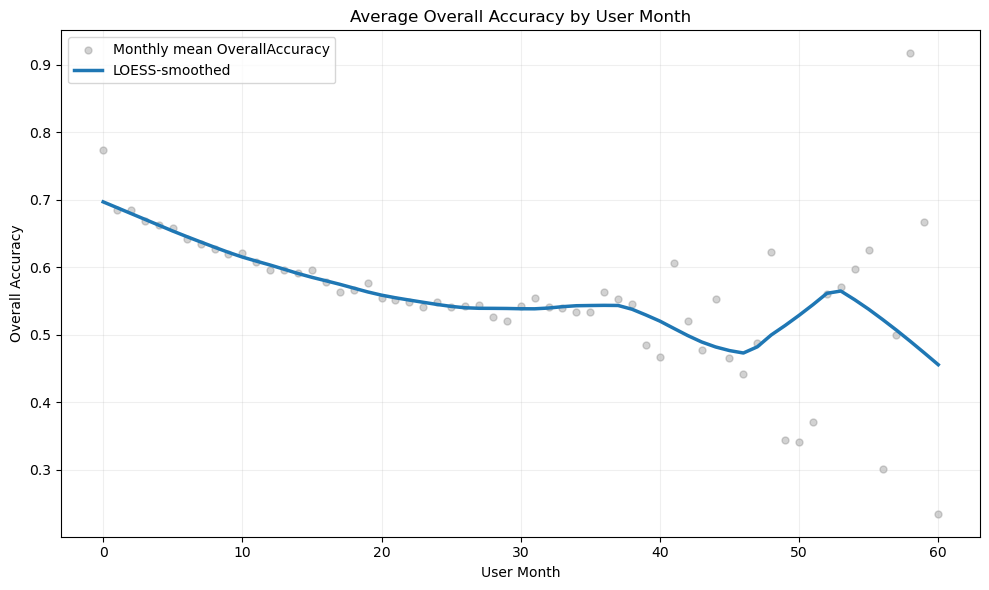

In [28]:
# Plot OverallAccuracy by userMonth with LOESS smoothing
overall_accuracy_df = ratings[["userMonth", "overallAccuracy"]].dropna().copy()
monthly_accuracy = (
    overall_accuracy_df
    .groupby("userMonth", as_index=False)["overallAccuracy"]
    .mean()
    .sort_values("userMonth")
)

loess_accuracy = lowess(
    monthly_accuracy["overallAccuracy"],
    monthly_accuracy["userMonth"],
    frac=0.2,
    return_sorted=True
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    monthly_accuracy["userMonth"],
    monthly_accuracy["overallAccuracy"],
    color="tab:gray",
    alpha=0.35,
    s=25,
    label="Monthly mean OverallAccuracy"
)
ax.plot(
    loess_accuracy[:, 0],
    loess_accuracy[:, 1],
    color="tab:blue",
    linewidth=2.5,
    label="LOESS-smoothed"
)

ax.set_title("Average Overall Accuracy by User Month")
ax.set_xlabel("User Month")
ax.set_ylabel("Overall Accuracy")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

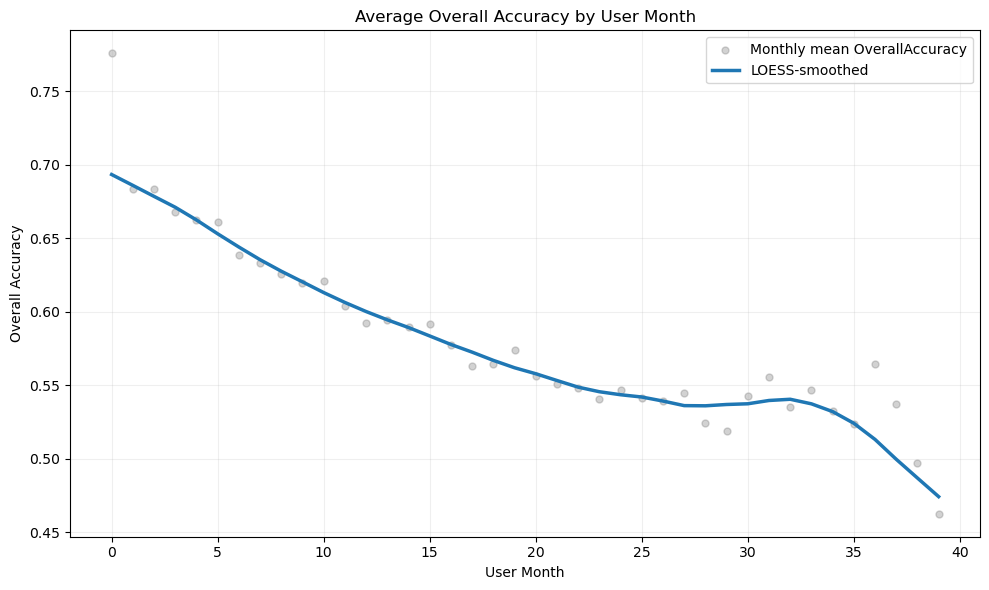

In [92]:
# Sort ratings by calendarMonth descending
ratings_sorted_desc = ratings.sort_values("calendarMonth", ascending=False)

# Find the last entry with calendarMonth == "2022-11"
last_2022_11_idx = ratings_sorted_desc[ratings_sorted_desc["calendarMonth"] == "2022-10"].index[-1]

# Get all entries below this index
below_last_2022_11 = ratings_sorted_desc.loc[last_2022_11_idx+1:]

# Drop all userIDs from these entries in the original ratings DataFrame
drop_user_ids = below_last_2022_11["raterParticipantId"].unique()
ratings_post_elon = ratings[~ratings["raterParticipantId"].isin(drop_user_ids)]

overall_accuracy_df = ratings[
    ratings["raterParticipantId"].isin(eligible_users)
][["userMonth", "overallAccuracy"]].dropna().copy()
# Plot OverallAccuracy by userMonth with LOESS smoothing
overall_accuracy_df = ratings_post_elon[["userMonth", "overallAccuracy"]].dropna().copy()
monthly_accuracy = (
    overall_accuracy_df
    .groupby("userMonth", as_index=False)["overallAccuracy"]
    .mean()
    .sort_values("userMonth")
)

loess_accuracy = lowess(
    monthly_accuracy["overallAccuracy"],
    monthly_accuracy["userMonth"],
    frac=0.2,
    return_sorted=True
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    monthly_accuracy["userMonth"],
    monthly_accuracy["overallAccuracy"],
    color="tab:gray",
    alpha=0.35,
    s=25,
    label="Monthly mean OverallAccuracy"
)
ax.plot(
    loess_accuracy[:, 0],
    loess_accuracy[:, 1],
    color="tab:blue",
    linewidth=2.5,
    label="LOESS-smoothed"
)

ax.set_title("Average Overall Accuracy by User Month")
ax.set_xlabel("User Month")
ax.set_ylabel("Overall Accuracy")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

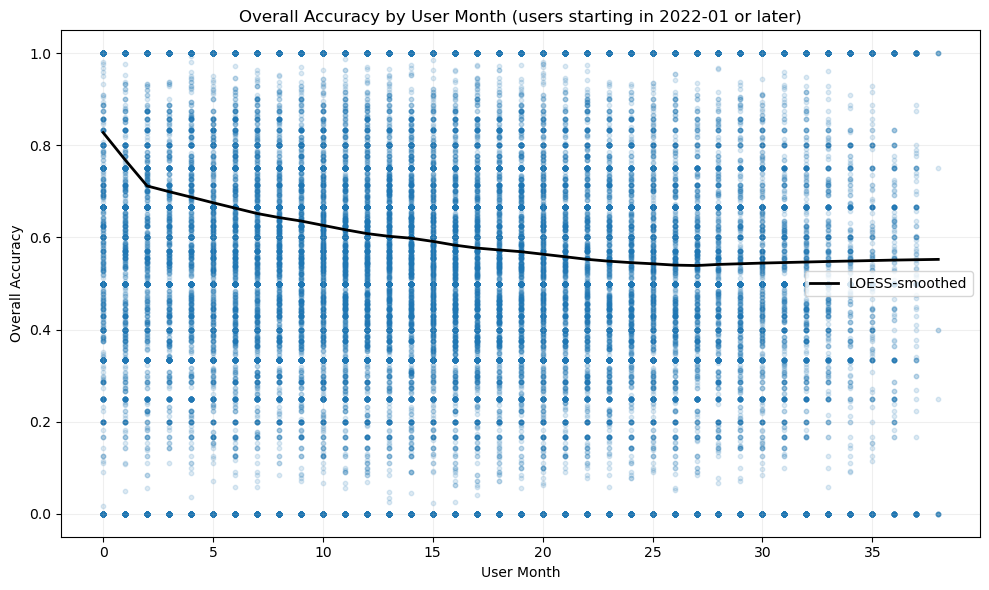

In [95]:
# Sort ratings by calendarMonth descending
ratings_sorted_desc = ratings.sort_values("calendarMonth", ascending=False)

# Find the last entry with calendarMonth == "2022-03"
last_2022_11_idx = ratings_sorted_desc[ratings_sorted_desc["calendarMonth"] == "2022-10"].index[-1]

# Get all entries below this index
below_last_2022_11 = ratings_sorted_desc.loc[last_2022_11_idx+1:]

# Drop all userIDs from these entries in the original ratings DataFrame
drop_user_ids = below_last_2022_11["raterParticipantId"].unique()
ratings_post_elon = ratings[~ratings["raterParticipantId"].isin(drop_user_ids)]

# Recreate the overall accuracy scatter + LOESS plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    overall_accuracy_filtered["userMonth"],
    overall_accuracy_filtered["overallAccuracy"],
    alpha=0.15,
    s=10,
    color="tab:blue"
)

loess_line_filtered = lowess(
    overall_accuracy_filtered["overallAccuracy"],
    overall_accuracy_filtered["userMonth"],
    frac=0.2,
    return_sorted=True
)

ax.plot(
    loess_line_filtered[:, 0],
    loess_line_filtered[:, 1],
    color="black",
    linewidth=2,
    label="LOESS-smoothed"
)

ax.set_title("Overall Accuracy by User Month (users starting in 2022-01 or later)")
ax.set_xlabel("User Month")
ax.set_ylabel("Overall Accuracy")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


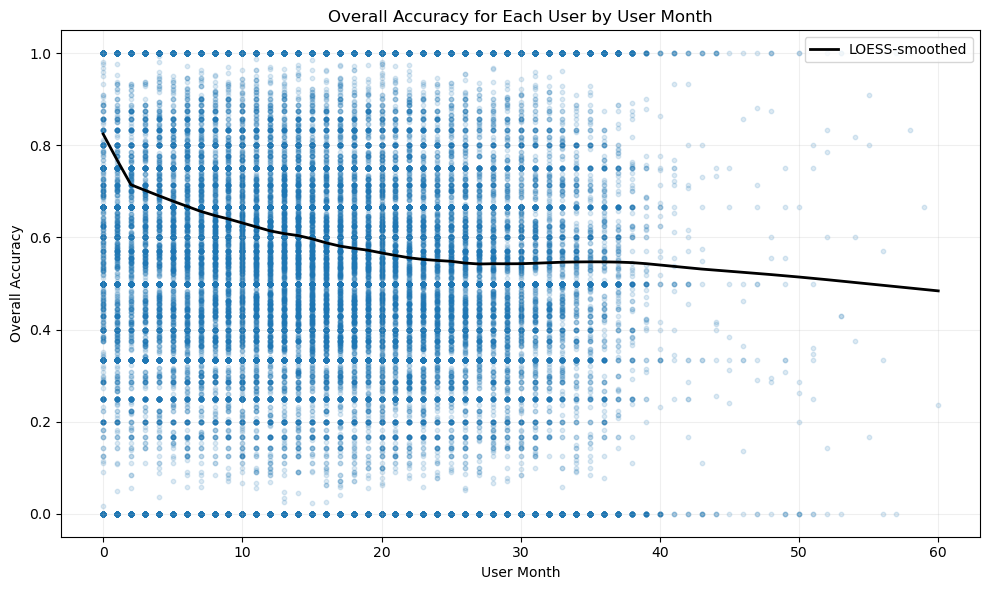

In [31]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    overall_accuracy_df["userMonth"],
    overall_accuracy_df["overallAccuracy"],
    alpha=0.15,
    s=10,
    color="tab:blue"
)

# Compute LOESS-smoothed line
loess_line = lowess(
    overall_accuracy_df["overallAccuracy"],
    overall_accuracy_df["userMonth"],
    frac=0.2,
    return_sorted=True
)
ax.plot(
    loess_line[:, 0],
    loess_line[:, 1],
    color="black",
    linewidth=2,
    label="LOESS-smoothed"
)

ax.set_title("Overall Accuracy for Each User by User Month")
ax.set_xlabel("User Month")
ax.set_ylabel("Overall Accuracy")
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()